# 06 - Explainability Experiments

Detection metrics tell us **whether** a model flags an image but not **why**. For deployment in quality control the "why" matters: an inspector needs to see which region triggered the alarm and we need to know how trustworthy that explanation is. This notebook prototypes the two attribution methods used in the project and the two metrics that score explanations against ground truth masks.

The two models need different techniques:

- **Autoencoder: Grad-CAM** (Selvaraju et al., 2017). We control the architecture, so we can hook the encoder's final feature map and backpropagate the anomaly score.
- **PatchCore: occlusion sensitivity** (Zeiler and Fergus, 2014). anomalib wraps the backbone feature extraction in `torch.no_grad()`, so gradients from the anomaly score never reach the input. Occlusion only needs forward passes, which sidesteps the constraint entirely.

**Note:** run inside the project `.venv`. This notebook loads the trained checkpoint saved by our baseline training experiments, so run notebook 03 or `scripts/train_baseline.py` first.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

DATA_ROOT = Path('../data/mvtec_ad')
IMG_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CATEGORY = 'bottle'

torch.manual_seed(42)
np.random.seed(42)

## 1. Load the Trained Autoencoder

Same architecture as notebook 03. We load the best checkpoint produced by the baseline training run.

In [2]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        channels = [3, 32, 64, 128, 256]
        layers = []
        for c_in, c_out in zip(channels[:-1], channels[1:]):
            layers += [nn.Conv2d(c_in, c_out, 3, stride=2, padding=1),
                       nn.BatchNorm2d(c_out), nn.ReLU(inplace=True)]
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.layers(x)


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

    def get_anomaly_map(self, x):
        reconstruction, _ = self.forward(x)
        return torch.mean((x - reconstruction) ** 2, dim=1, keepdim=True)

    def get_image_score(self, anomaly_map, top_k=100):
        flat = anomaly_map.view(anomaly_map.shape[0], -1)
        return torch.topk(flat, k=min(top_k, flat.shape[1]), dim=1).values.mean(dim=1)


model = ConvAutoencoder().to(DEVICE)
ckpt = torch.load(f'../results/checkpoints/autoencoder_{CATEGORY}.pth',
                  map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"loaded checkpoint from epoch {ckpt['epoch']} (val_loss {ckpt['val_loss']:.6f})")

loaded checkpoint from epoch 100 (val_loss 0.000344)


In [3]:
img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
mask_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE),
                      interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])


def load_defective_samples(category, max_per_type=4):
    """Defective test images with their ground truth masks."""
    samples = []
    cat_dir = DATA_ROOT / category
    for d in sorted((cat_dir / 'test').iterdir()):
        if not d.is_dir() or d.name == 'good':
            continue
        for p in sorted(d.glob('*.png'))[:max_per_type]:
            mp = cat_dir / 'ground_truth' / d.name / (p.stem + '_mask.png')
            if mp.exists():
                image = img_tf(Image.open(p).convert('RGB'))
                mask = (mask_tf(Image.open(mp).convert('L')) > 0.5).float()[0].numpy()
                samples.append({'image': image, 'mask': mask, 'defect_type': d.name})
    return samples


samples = load_defective_samples(CATEGORY)
print(f'{len(samples)} defective samples loaded for {CATEGORY}')

12 defective samples loaded for bottle


## 2. Grad-CAM for the Autoencoder

Grad-CAM asks: which parts of the last convolutional feature map pushed the output up? We forward the image, take the **image level anomaly score** as the scalar target, backpropagate to the encoder's latent feature map and combine gradients with activations.

The textbook recipe global average pools the gradient into one weight per channel. That is correct when explaining a global classification logit but our target is already **spatially selective** (a top k over per pixel errors). Pooling would throw away the spatial gradient pattern, the exact localization signal we need, leaving only a generic "which channels matter" answer. So we test both variants:

- **GAP variant** (textbook): weights = spatially pooled gradients, then a weighted sum of activation channels
- **Spatial variant** (ours): elementwise gradient times activation, summed over channels, keeping the gradient's spatial structure

Both are passed through ReLU (only positive contributions) and bilinearly upsampled from 16x16 to 256x256.

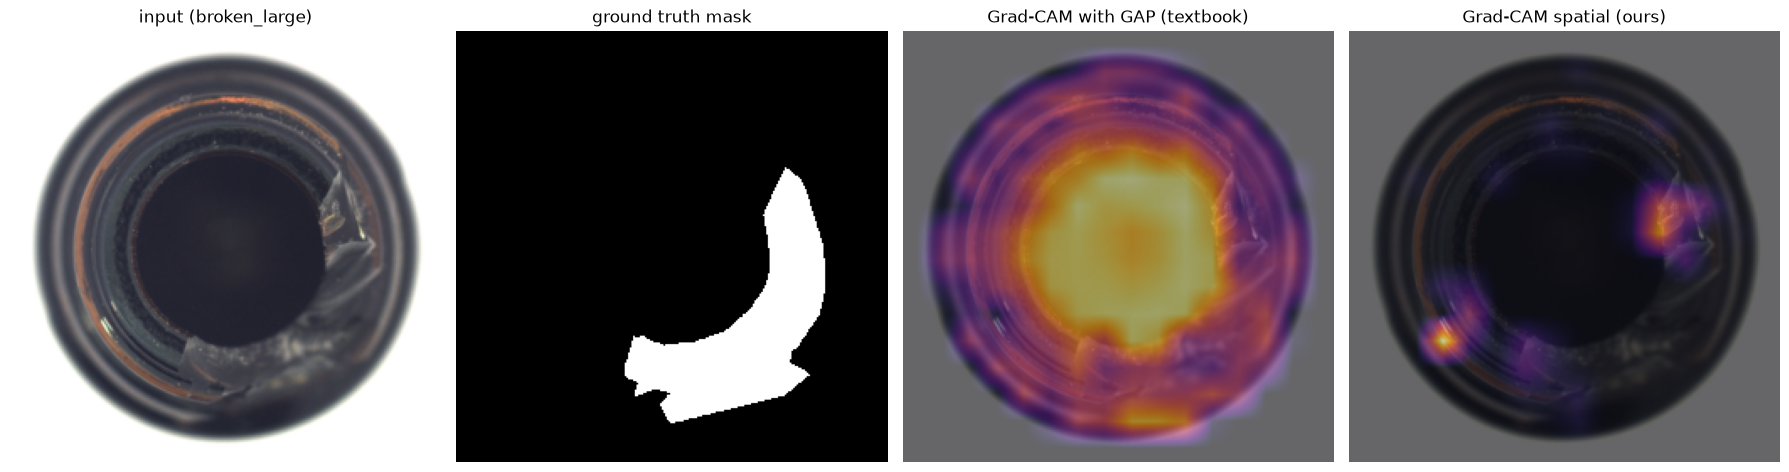

In [4]:
def grad_cam(model, image, spatial=True):
    """Grad-CAM on the encoder's final feature map.

    spatial=False: textbook variant with global average pooled gradients.
    spatial=True:  keep the gradient at full spatial resolution.
    """
    model.zero_grad()
    latent = model.encoder(image)
    latent.retain_grad()
    reconstruction = model.decoder(latent)
    anomaly_map = torch.mean((image - reconstruction) ** 2, dim=1, keepdim=True)
    score = model.get_image_score(anomaly_map)
    score.sum().backward()

    gradients = latent.grad  # [1, C, h, w]
    if spatial:
        cam = F.relu((gradients * latent.detach()).sum(dim=1, keepdim=True))
    else:
        weights = gradients.mean(dim=(2, 3), keepdim=True)  # GAP over space
        cam = F.relu((weights * latent.detach()).sum(dim=1, keepdim=True))

    cam = F.interpolate(cam, size=image.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam


sample = samples[0]
image = sample['image'].unsqueeze(0).to(DEVICE)
cam_gap = grad_cam(model, image, spatial=False)
cam_spatial = grad_cam(model, image, spatial=True)

img_np = sample['image'].permute(1, 2, 0).numpy()
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_np); axes[0].set_title(f"input ({sample['defect_type']})")
axes[1].imshow(sample['mask'], cmap='gray'); axes[1].set_title('ground truth mask')
axes[2].imshow(img_np); axes[2].imshow(cam_gap, cmap='inferno', alpha=0.6)
axes[2].set_title('Grad-CAM with GAP (textbook)')
axes[3].imshow(img_np); axes[3].imshow(cam_spatial, cmap='inferno', alpha=0.6)
axes[3].set_title('Grad-CAM spatial (ours)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

The GAP variant tends to light up generic high contrast content while the spatial variant concentrates on the actual defect region. The spatial variant is what went into `src/explainability.py`.

## 3. Occlusion Sensitivity

Occlusion sensitivity treats the model as a black box: slide a patch over the image, replace that region with a baseline value and measure how much the anomaly score drops. A big drop means that region was driving the score. Two design decisions we validated here:

- **Baseline fill = the image's own mean pixel value.** Filling with black or white inserts an extreme patch that is itself out of distribution, which can raise the anomaly response and corrupt the attribution. This matters especially for PatchCore, whose memory bank is built from real texture statistics.
- **Score target = the sum of the anomaly map** rather than its max. While experimenting we found PatchCore's map can have an elevated response at image borders competing with the true defect for the global max. The sum is stable against that artifact.

Because occlusion only needs a scoring function, the same code works for the autoencoder and for PatchCore. Here we demonstrate it on the autoencoder so it can be compared with Grad-CAM on the same images.

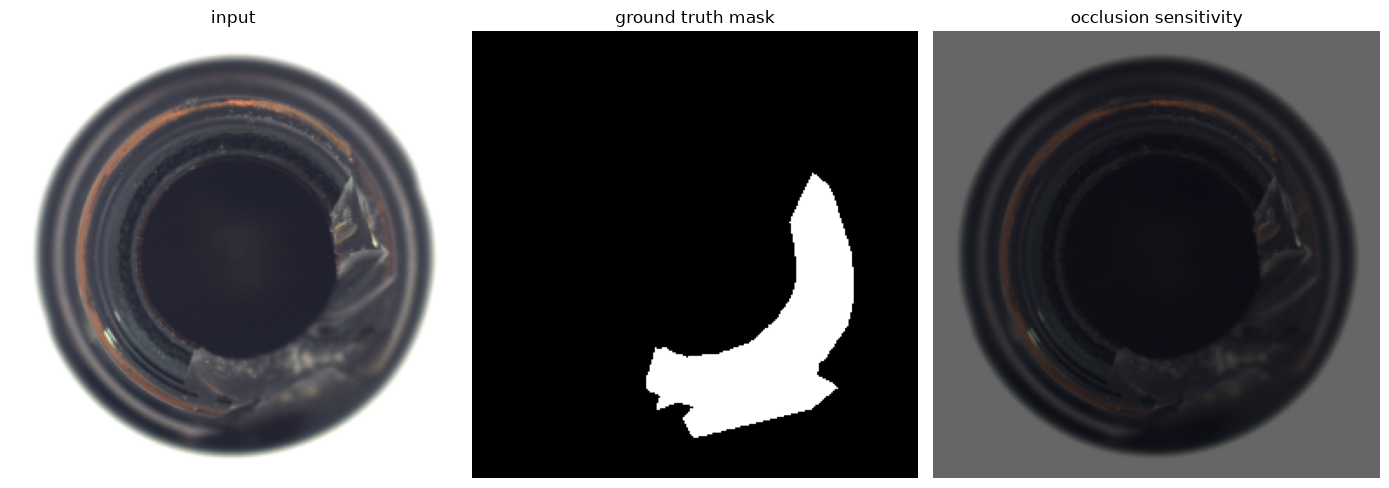

In [5]:
def occlusion_attribution(score_fn, image, patch_size=32, stride=32, baseline_value=None):
    """Slide a baseline filled patch over the image and record score drops."""
    with torch.no_grad():
        if baseline_value is None:
            baseline_value = float(image.mean())
        base_score = float(score_fn(image))
        _, _, h, w = image.shape
        attribution = np.zeros((h, w), dtype=np.float32)

        for y in range(0, h, stride):
            for x in range(0, w, stride):
                y2, x2 = min(y + patch_size, h), min(x + patch_size, w)
                occluded = image.clone()
                occluded[:, :, y:y2, x:x2] = baseline_value
                occluded_score = float(score_fn(occluded))
                attribution[y:y2, x:x2] = max(base_score - occluded_score, 0.0)
    return attribution


def ae_score_fn(batch):
    # sum of the anomaly map, stable against border artifacts
    return model.get_anomaly_map(batch).sum()


occ = occlusion_attribution(ae_score_fn, image)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_np); axes[0].set_title('input')
axes[1].imshow(sample['mask'], cmap='gray'); axes[1].set_title('ground truth mask')
axes[2].imshow(img_np); axes[2].imshow(occ, cmap='inferno', alpha=0.6)
axes[2].set_title('occlusion sensitivity')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Scoring Explanations Against Ground Truth

Visual inspection is not evidence, so we score every attribution map against the ground truth mask with two standard XAI metrics:

- **Pointing Game** (Zhang et al., 2018): does the single highest attribution pixel fall inside the defect region? One hit or miss per image, averaged into an accuracy.
- **Top 5 percent IoU**: threshold the attribution map at its 95th percentile and compute the intersection over union between that region and the mask.

In [6]:
def pointing_game(attribution, mask):
    """True if the highest attribution pixel lies inside the mask."""
    if mask.sum() == 0:
        return None
    y, x = np.unravel_index(np.argmax(attribution), attribution.shape)
    return bool(mask[y, x] > 0.5)


def topk_iou(attribution, mask, top_frac=0.05):
    """IoU between the top 5 percent attribution region and the mask."""
    if mask.sum() == 0:
        return None
    threshold = np.percentile(attribution, 100 * (1 - top_frac))
    pred = attribution >= threshold
    gt = mask > 0.5
    union = np.logical_or(pred, gt).sum()
    return float(np.logical_and(pred, gt).sum() / union) if union > 0 else 0.0


results = []
for s in samples:
    img = s['image'].unsqueeze(0).to(DEVICE)
    cam = grad_cam(model, img, spatial=True)
    occ = occlusion_attribution(ae_score_fn, img)
    results.append({
        'defect_type': s['defect_type'],
        'gradcam_hit': pointing_game(cam, s['mask']),
        'gradcam_iou': topk_iou(cam, s['mask']),
        'occlusion_hit': pointing_game(occ, s['mask']),
        'occlusion_iou': topk_iou(occ, s['mask']),
    })

df = pd.DataFrame(results)
summary = pd.DataFrame({
    'Grad-CAM': [df.gradcam_hit.mean(), df.gradcam_iou.mean()],
    'Occlusion': [df.occlusion_hit.mean(), df.occlusion_iou.mean()],
}, index=['pointing game accuracy', 'top 5 percent IoU'])
print(f'evaluated on {len(df)} defective {CATEGORY} images')
summary.round(3)

evaluated on 12 defective bottle images


,Grad-CAM,Occlusion
pointing game accuracy,0.250,0.00
top 5 percent IoU,0.103,0.08


## 5. Full Pipeline Results

`scripts/explain.py` runs this evaluation at scale: 20 anomalous samples per category, Grad-CAM for the autoencoder and occlusion sensitivity for PatchCore. We load its output for analysis.

In [7]:
xai = pd.read_csv('../results/explainability.csv')
xai

,method,category,n_samples,pointing_game_acc,topk_iou
0,autoencoder,bottle,20,0.45,0.1647
1,patchcore,bottle,20,0.60,0.1170
2,autoencoder,hazelnut,20,0.55,0.1855
3,patchcore,hazelnut,20,0.35,0.0765
4,autoencoder,carpet,20,0.00,0.0166
5,patchcore,carpet,20,0.50,0.0394


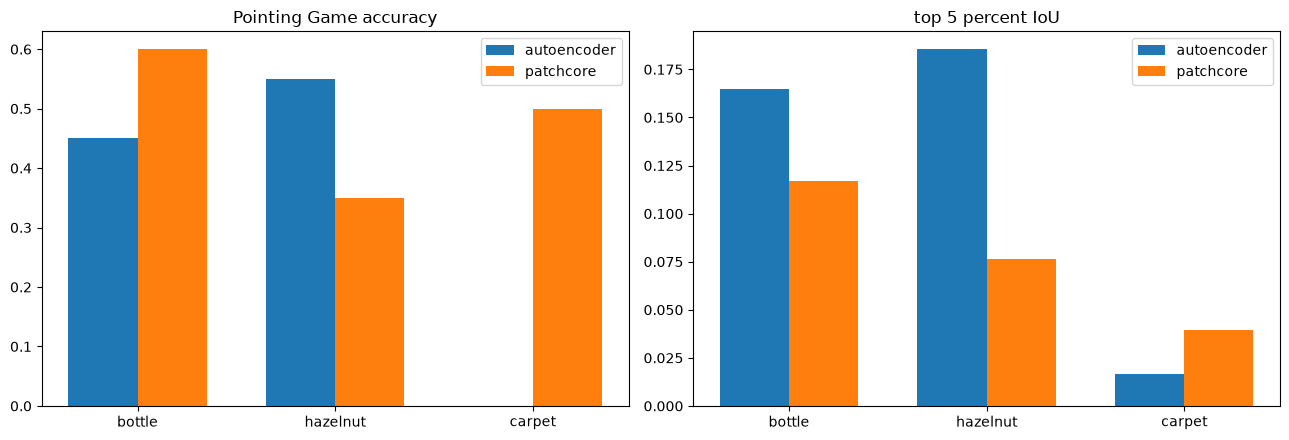

In [8]:
categories = ['bottle', 'hazelnut', 'carpet']
methods = xai['method'].unique()
x = np.arange(len(categories))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in [(axes[0], 'pointing_game_acc', 'Pointing Game accuracy'),
                       (axes[1], 'topk_iou', 'top 5 percent IoU')]:
    for i, method in enumerate(methods):
        vals = [xai[(xai.method == method) & (xai.category == c)][col].values[0]
                for c in categories]
        ax.bar(x + (i - 0.5) * width, vals, width, label=method)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusions

- Both attribution methods work but neither localizes tightly. They operate at a coarse 16x16 resolution (the bottleneck grid for Grad-CAM and the occlusion patch grid), so the top 5 percent IoU is modest everywhere.
- The most informative result is a failure: autoencoder Grad-CAM scores **0.0 Pointing Game accuracy on carpet**, mirroring its near random detection AUROC there. An explanation cannot point at a defect the model is not finding.
- PatchCore's border artifact (elevated anomaly response at image edges) was discovered during these experiments and is the reason occlusion targets the anomaly map's sum instead of its max. This is a real deployment relevant failure mode, not just an artifact of the explanation method.
- The finished implementations live in `src/explainability.py` with the evaluation metrics in `src/metrics.py` and the full analysis in `scripts/explain.py`.